# Comparing the similarity between different documents (songs) using Cosine Similarity

## First, lets only use a few selected words and a pure numpy implementation for the cosine similarity

In [2]:
import numpy as np
import pandas as pd

### Read data

In [ ]:
df = pd.read_csv("DotProductCounts.csv", index_col=0, delimiter=";")

In [ ]:
df

,I,She,eye,me,like,when,weak,Hey,new,complaint,...,black,never,dirty,thing,seduce,boys,sleeping,tired,tonight,home
MyLyrics1,16,2,0,2,2,4,2,9,9,9,...,3,0,0,0,0,0,0,0,0,0
MyLyrics2,16,2,6,2,2,4,2,9,9,9,...,3,0,0,0,0,0,0,0,0,0
MyLyrics3,13,13,0,7,0,1,0,2,0,0,...,0,1,21,2,2,1,1,1,2,2


### Instantialize vectors

In [ ]:
l1_vec = np.array(df.iloc[0].values)
l2_vec = np.array(df.iloc[1].values)
l3_vec = np.array(df.iloc[2].values)

### Cosine Similarity Function

The cosine similarity between two vectors $A$ and $B$ is defined as:
$$\cos(\theta) = \frac{A \cdot B}{||A|| \times ||B||}$$

In [26]:
def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray):
    dot_prod = np.dot(vec1, vec2)

    vec1_length = np.linalg.norm(vec1)
    vec2_length = np.linalg.norm(vec2)

    if vec1_length == 0 or vec2_length == 0:
        return 0

    return dot_prod / (vec1_length * vec2_length)


### Cosine Similarity between Document 1 and Document 2 (Document two is basically Document 1 with just a little more text added to it)

In [ ]:
cosine_similarity(l1_vec, l2_vec)

np.float64(0.9055385138137416)

In [ ]:
print(f"Angle in radians: {np.arccos(cosine_similarity(l1_vec, l2_vec))}")
print(f"Angle in degrees: {np.rad2deg(np.arccos(cosine_similarity(l1_vec, l2_vec)))}")

Angle in radians: 0.43814903058417043
Angle in degrees: 25.104090250221393


### Cosine Similarity between Document 1 and Document 3

In [ ]:
cosine_similarity(l1_vec, l3_vec)

np.float64(0.318206890737013)

In [ ]:
print(f"Angle in radians: {np.arccos(cosine_similarity(l1_vec, l3_vec))}")
print(f"Angle in degrees: {np.rad2deg(np.arccos(cosine_similarity(l1_vec, l3_vec)))}")

Angle in radians: 1.2469588643897682
Angle in degrees: 71.44548015595969


### Cosine Similarity between Document 2 and Document 3

In [ ]:
cosine_similarity(l2_vec, l3_vec)

np.float64(0.32016510547031835)

In [ ]:
print(f"Angle in radians: {np.arccos(cosine_similarity(l2_vec, l3_vec))}")
print(f"Angle in degrees: {np.rad2deg(np.arccos(cosine_similarity(l2_vec, l3_vec)))}")

Angle in radians: 1.2448925654097351
Angle in degrees: 71.3270899451916


## Now, lets use the full vocabulary and do some more analysis

In [3]:
import re
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_colwidth', 300)

In [8]:
df = pd.read_csv("SongLyrics.csv", delimiter=",")

In [9]:
df

,document,text
0,MyLyrics1,Well my buckle makes impressions\nOn the inside of her thigh\nThere are little feathered Indians\nWhere we tussled through the night\nIf I'd known she was religious\nThen I wouldn't have came stoned\nTo the house of such an angel\nToo fucked up to get back home\nLooking over West Virginia\nSmoki...
1,MyLyrics2,We don't talk about you often but you're from forgotten\nBeen forever since we've seen your face\nBut there ain't nothing against you\nIt's just easier to live through this life\nThinking you're one call away\nOnly one call away\nAnd ever since the day you parted\nYou left us all so broken-heart...
2,MyLyrics3,"And I remember all those summers\nPlaying 'til my fingers bled\nYou'd sing songs and I'd sing with you\nWe'd get drunk and go to bed\nLooking back at all them memories\nLord, I hate to sleep alone\nIf you ever get the notion\nThat you need me, let me know\n'Cause it's just two hours, get there, ..."


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  3 non-null      object
 1   text      3 non-null      object
dtypes: object(2)
memory usage: 180.0+ bytes


In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Functions for processing text

In [15]:
def remove_punct(text):
    text_nopunct = "".join([char for char in text if char not in string.punctuation])
    return text_nopunct

def tokenize(text):
    tokens = re.split('\W+', text)
    return tokens

stopwords = nltk.corpus.stopwords.words('english')
ps = nltk.PorterStemmer()
def remove_stopwords(tokenized_list):
    text = [ps.stem(word) for word in tokenized_list if word not in stopwords]
    return text

def clean_text(text):
    text = "".join([word.lower() for word in text if word not in string.punctuation])
    tokens = re.split('\W+', text)
    text = [ps.stem(word) for word in tokens if word not in stopwords]
    return text

def remove_newlines(text: str):
    return text.replace('\n', ' ').replace('\r', ' ')

<>:6: SyntaxWarning: invalid escape sequence '\W'
<>:17: SyntaxWarning: invalid escape sequence '\W'
<>:6: SyntaxWarning: invalid escape sequence '\W'
<>:17: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipython-input-4268086734.py:6: SyntaxWarning: invalid escape sequence '\W'
  tokens = re.split('\W+', text)
/tmp/ipython-input-4268086734.py:17: SyntaxWarning: invalid escape sequence '\W'
  tokens = re.split('\W+', text)


In [16]:
df["text"] = df["text"].apply(lambda x: remove_newlines(x))

In [17]:
df['text_nopunct'] = df['text'].apply(lambda x: remove_punct(x))
df['text_tokenized'] = df['text_nopunct'].apply(lambda x: tokenize(x))
df['text_nostopw'] = df['text_tokenized'].apply(lambda x: remove_stopwords(x))

In [18]:
df.head()

,document,text,text_nopunct,text_tokenized,text_nostopw
0,MyLyrics1,Well my buckle makes impressions On the inside of her thigh There are little feathered Indians Where we tussled through the night If I'd known she was religious Then I wouldn't have came stoned To the house of such an angel Too fucked up to get back home Looking over West Virginia Smoking Spirit...,Well my buckle makes impressions On the inside of her thigh There are little feathered Indians Where we tussled through the night If Id known she was religious Then I wouldnt have came stoned To the house of such an angel Too fucked up to get back home Looking over West Virginia Smoking Spirits ...,"[Well, my, buckle, makes, impressions, On, the, inside, of, her, thigh, There, are, little, feathered, Indians, Where, we, tussled, through, the, night, If, Id, known, she, was, religious, Then, I, wouldnt, have, came, stoned, To, the, house, of, such, an, angel, Too, fucked, up, to, get, back, ...","[well, buckl, make, impress, on, insid, thigh, there, littl, feather, indian, where, tussl, night, if, id, known, religi, then, i, wouldnt, came, stone, to, hous, angel, too, fuck, get, back, home, look, west, virginia, smoke, spirit, roof, she, ask, aint, anybodi, told, ya, that, thing, bad, i,..."
1,MyLyrics2,We don't talk about you often but you're from forgotten Been forever since we've seen your face But there ain't nothing against you It's just easier to live through this life Thinking you're one call away Only one call away And ever since the day you parted You left us all so broken-hearted Memo...,We dont talk about you often but youre from forgotten Been forever since weve seen your face But there aint nothing against you Its just easier to live through this life Thinking youre one call away Only one call away And ever since the day you parted You left us all so brokenhearted Memories of...,"[We, dont, talk, about, you, often, but, youre, from, forgotten, Been, forever, since, weve, seen, your, face, But, there, aint, nothing, against, you, Its, just, easier, to, live, through, this, life, Thinking, youre, one, call, away, Only, one, call, away, And, ever, since, the, day, you, part...","[we, dont, talk, often, your, forgotten, been, forev, sinc, weve, seen, face, but, aint, noth, it, easier, live, life, think, your, one, call, away, onli, one, call, away, and, ever, sinc, day, part, you, left, us, brokenheart, memori, run, mind, well, i, found, old, contact, phone, book, back, ..."
2,MyLyrics3,"And I remember all those summers Playing 'til my fingers bled You'd sing songs and I'd sing with you We'd get drunk and go to bed Looking back at all them memories Lord, I hate to sleep alone If you ever get the notion That you need me, let me know 'Cause it's just two hours, get there, babe I c...",And I remember all those summers Playing til my fingers bled Youd sing songs and Id sing with you Wed get drunk and go to bed Looking back at all them memories Lord I hate to sleep alone If you ever get the notion That you need me let me know Cause its just two hours get there babe I can make it...,"[And, I, remember, all, those, summers, Playing, til, my, fingers, bled, Youd, sing, songs, and, Id, sing, with, you, Wed, get, drunk, and, go, to, bed, Looking, back, at, all, them, memories, Lord, I, hate, to, sleep, alone, If, you, ever, get, the, notion, That, you, need, me, let, me, know, C...","[and, i, rememb, summer, play, til, finger, bled, youd, sing, song, id, sing, wed, get, drunk, go, bed, look, back, memori, lord, i, hate, sleep, alon, if, ever, get, notion, that, need, let, know, caus, two, hour, get, babe, i, make, back, bout, hour, hold, close, skin, i, need, littl, warmth, ..."


### Document-Term Matrix

### Using CountVectorizer

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer(analyzer=clean_text) #Instatiating CountVectorizer()

X1_counts = count_vect.fit_transform(df['text'])

### Sample or subset of original matrix
scalar_multiple =  1 # fill in with a positive integer less than 7 to set sample size as a multiple of 5
rows_in_sample = (scalar_multiple)
data1_sample = df[0:rows_in_sample]
count_vect_sample1 = CountVectorizer(analyzer=clean_text)
X1_counts_sample = count_vect.fit_transform(data1_sample['text'])


#### What is the number of rows and columns for the original document-term matrix versus a sample?

In [20]:
print('Dimensions of original document-term matrix = {}'.format(X1_counts.shape))

Dimensions of original document-term matrix = (3, 217)


In [21]:
print('Dimensions of sample document-term matrix = {}'.format(X1_counts_sample.shape))

Dimensions of sample document-term matrix = (1, 86)


#### Color-Coded Representation of Matrices

The heat map is a color-coded representation of the entries of a matrix, where zero is coded with the color white and larger positive integer values are coded in the darker-color spectrum.

The original 5567-by-8104 document-term matrix is very sparse (that is, it has multiple entries equal to zero). Thus, its heat map representation displays most regions with tones ranging form light-blue to white.

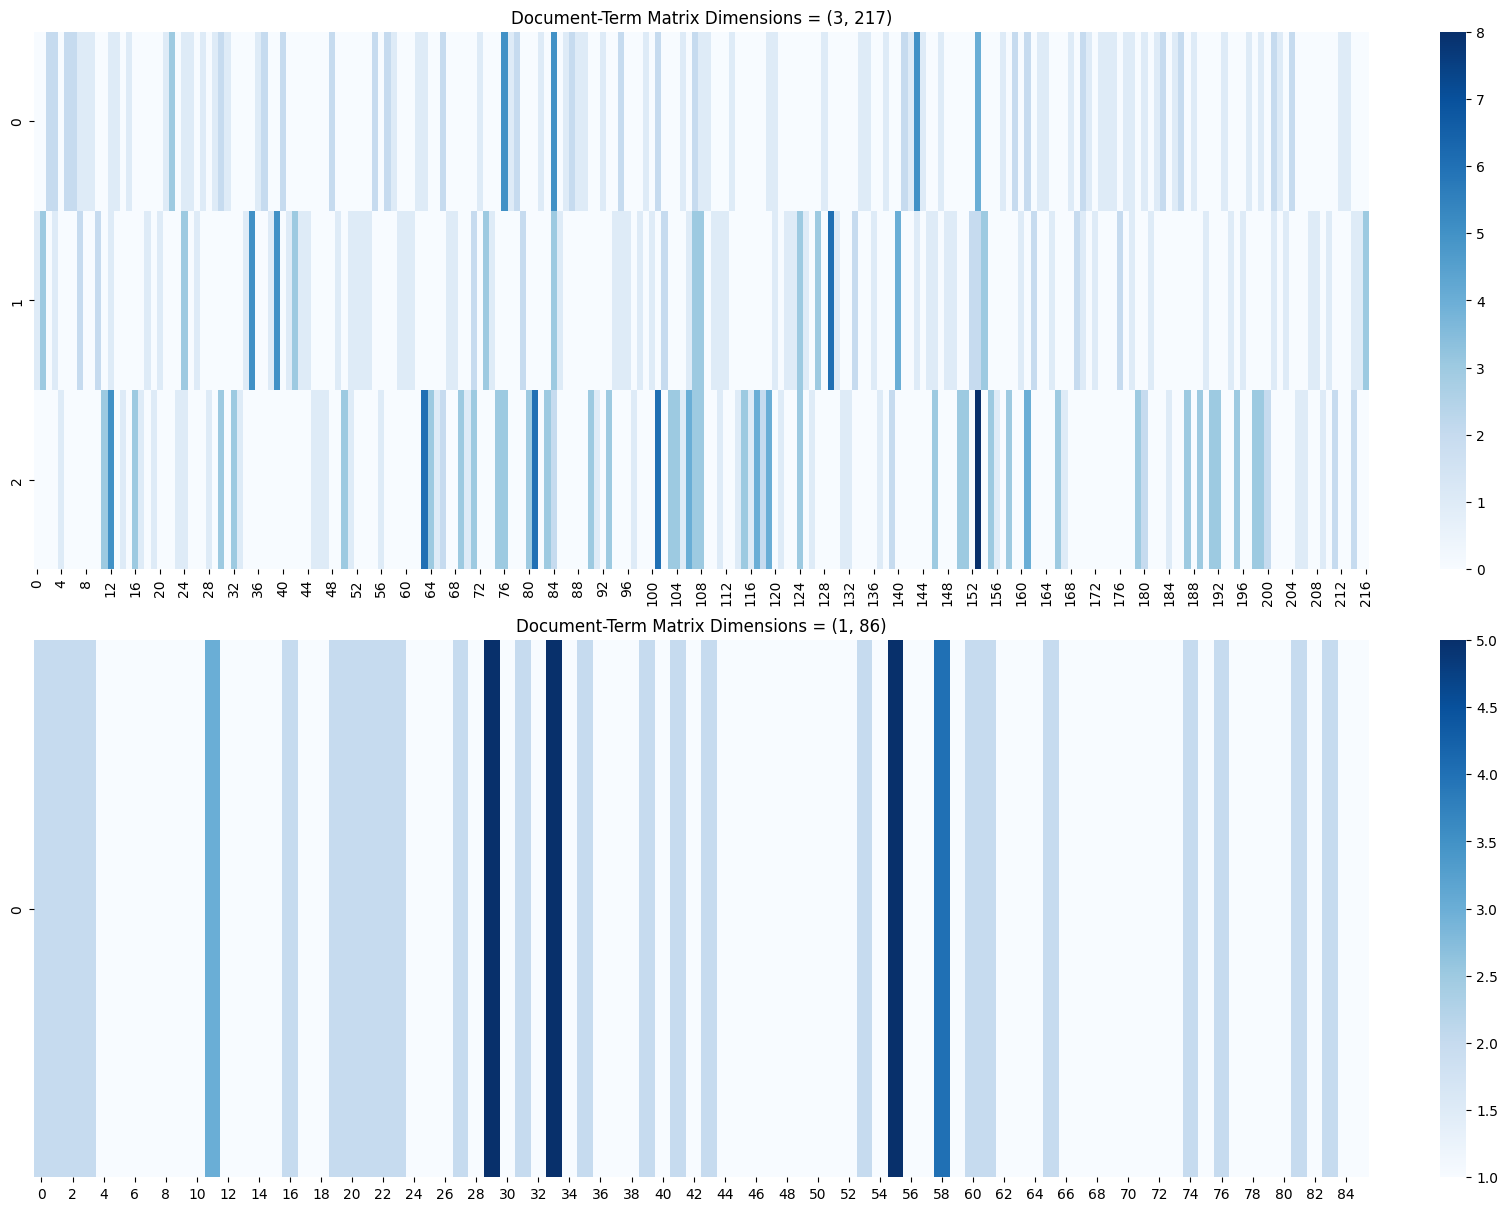

In [22]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(15,12),layout="constrained")
sns.heatmap(X1_counts.todense(),cmap='Blues',ax=axs[0])
axs[0].set_title('Document-Term Matrix Dimensions = {}'.format(X1_counts.shape))
sns.heatmap(X1_counts_sample.todense(),cmap='Blues',ax=axs[1])
axs[1].set_title('Document-Term Matrix Dimensions = {}'.format(X1_counts_sample.shape))
plt.show()

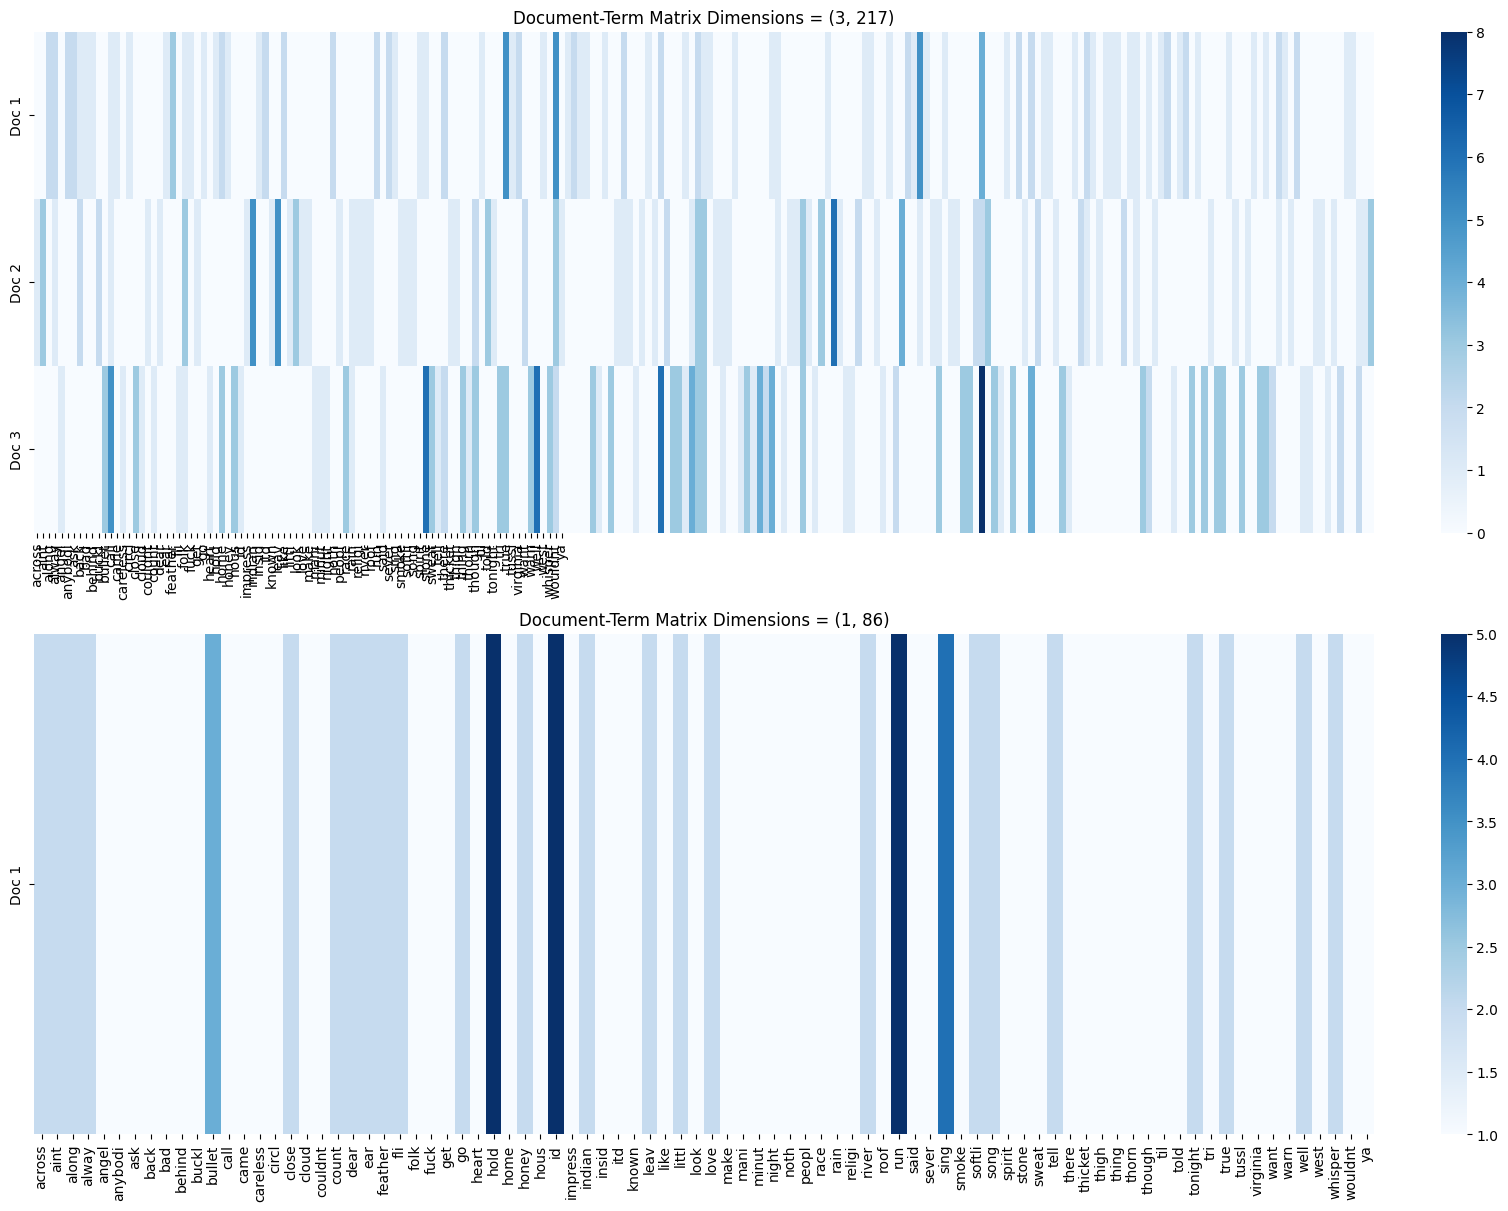

In [23]:
# show the graph but with the words along the axes
terms = count_vect.get_feature_names_out()
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(15,12),layout="constrained")
sns.heatmap(X1_counts.todense(),cmap='Blues',ax=axs[0], xticklabels=terms, yticklabels=[f'Doc {i+1}' for i in range(X1_counts.shape[0])])
sns.heatmap(X1_counts_sample.todense(),cmap='Blues',ax=axs[1], xticklabels=terms, yticklabels=[f'Doc {i+1}' for i in range(X1_counts_sample.shape[0])])
axs[0].set_title('Document-Term Matrix Dimensions = {}'.format(X1_counts.shape))
axs[1].set_title('Document-Term Matrix Dimensions = {}'.format(X1_counts_sample.shape))
plt.show()

In [24]:
# convert matrices to vectors for the cosine similarity calculations
vec1 = X1_counts[0].toarray().ravel()
vec2 = X1_counts[1].toarray().ravel()
vec3 = X1_counts[2].toarray().ravel()

#### Cosine similarity between first two documents

In [27]:
cosine_sim_one_two = cosine_similarity(vec1, vec2)
print(f"Cosine similarity between Doc1 and Do2: {cosine_sim_one_two}")
print(f"In radians: {np.arccos(cosine_sim_one_two)}")
print(f"In degrees: {np.rad2deg(np.arccos(cosine_sim_one_two))}")

Cosine similarity between Doc1 and Do2: 0.19110797786938555
In radians: 1.3785055215971806
In degrees: 78.9825484229986


#### Cosine similarity between the first and the third document

In [28]:


cosine_sim_one_three = cosine_similarity(vec1, vec3)
print(f"Cosine similarity between Doc1 and Do3: {cosine_sim_one_three}")
print(f"In radians: {np.arccos(cosine_sim_one_three)}")
print(f"In degrees: {np.rad2deg(np.arccos(cosine_sim_one_three))}")

Cosine similarity between Doc1 and Do3: 0.2953296611450126
In radians: 1.270995774467999
In degrees: 72.82269365597777


#### Cosine similarity between the second and the third document

In [29]:
# Cosine similarity between second and third documents
cosine_sim_two_three = cosine_similarity(vec2, vec3)
print(f"Cosine similarity between Doc2 and Do3: {cosine_sim_two_three}")
print(f"In radians: {np.arccos(cosine_sim_two_three)}")
print(f"In degrees: {np.rad2deg(np.arccos(cosine_sim_two_three))}")

Cosine similarity between Doc2 and Do3: 0.16895857900079078
In radians: 1.4010233653158461
In degrees: 80.2727258318133


#### Visualize the cosine similarity matrix for the sample data

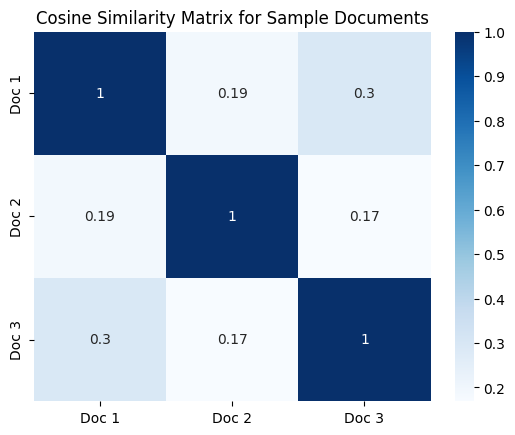

In [30]:

from sklearn.metrics.pairwise import cosine_similarity
cosine_sim_matrix = cosine_similarity(X1_counts)
sns.heatmap(cosine_sim_matrix, annot=True, cmap='Blues', xticklabels=[f'Doc {i+1}' for i in range(X1_counts.shape[0])], yticklabels=[f'Doc {i+1}' for i in range(X1_counts.shape[0])])
plt.title('Cosine Similarity Matrix for Sample Documents')
plt.show()

## Let's see how the cosine similarity changes when we use TF-IDF instead of simple counts

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(analyzer=clean_text)
X1_tfidf = tfidf_vect.fit_transform(df['text'])
X1_tfidf.toarray()
X1_tfidf.shape

(3, 217)

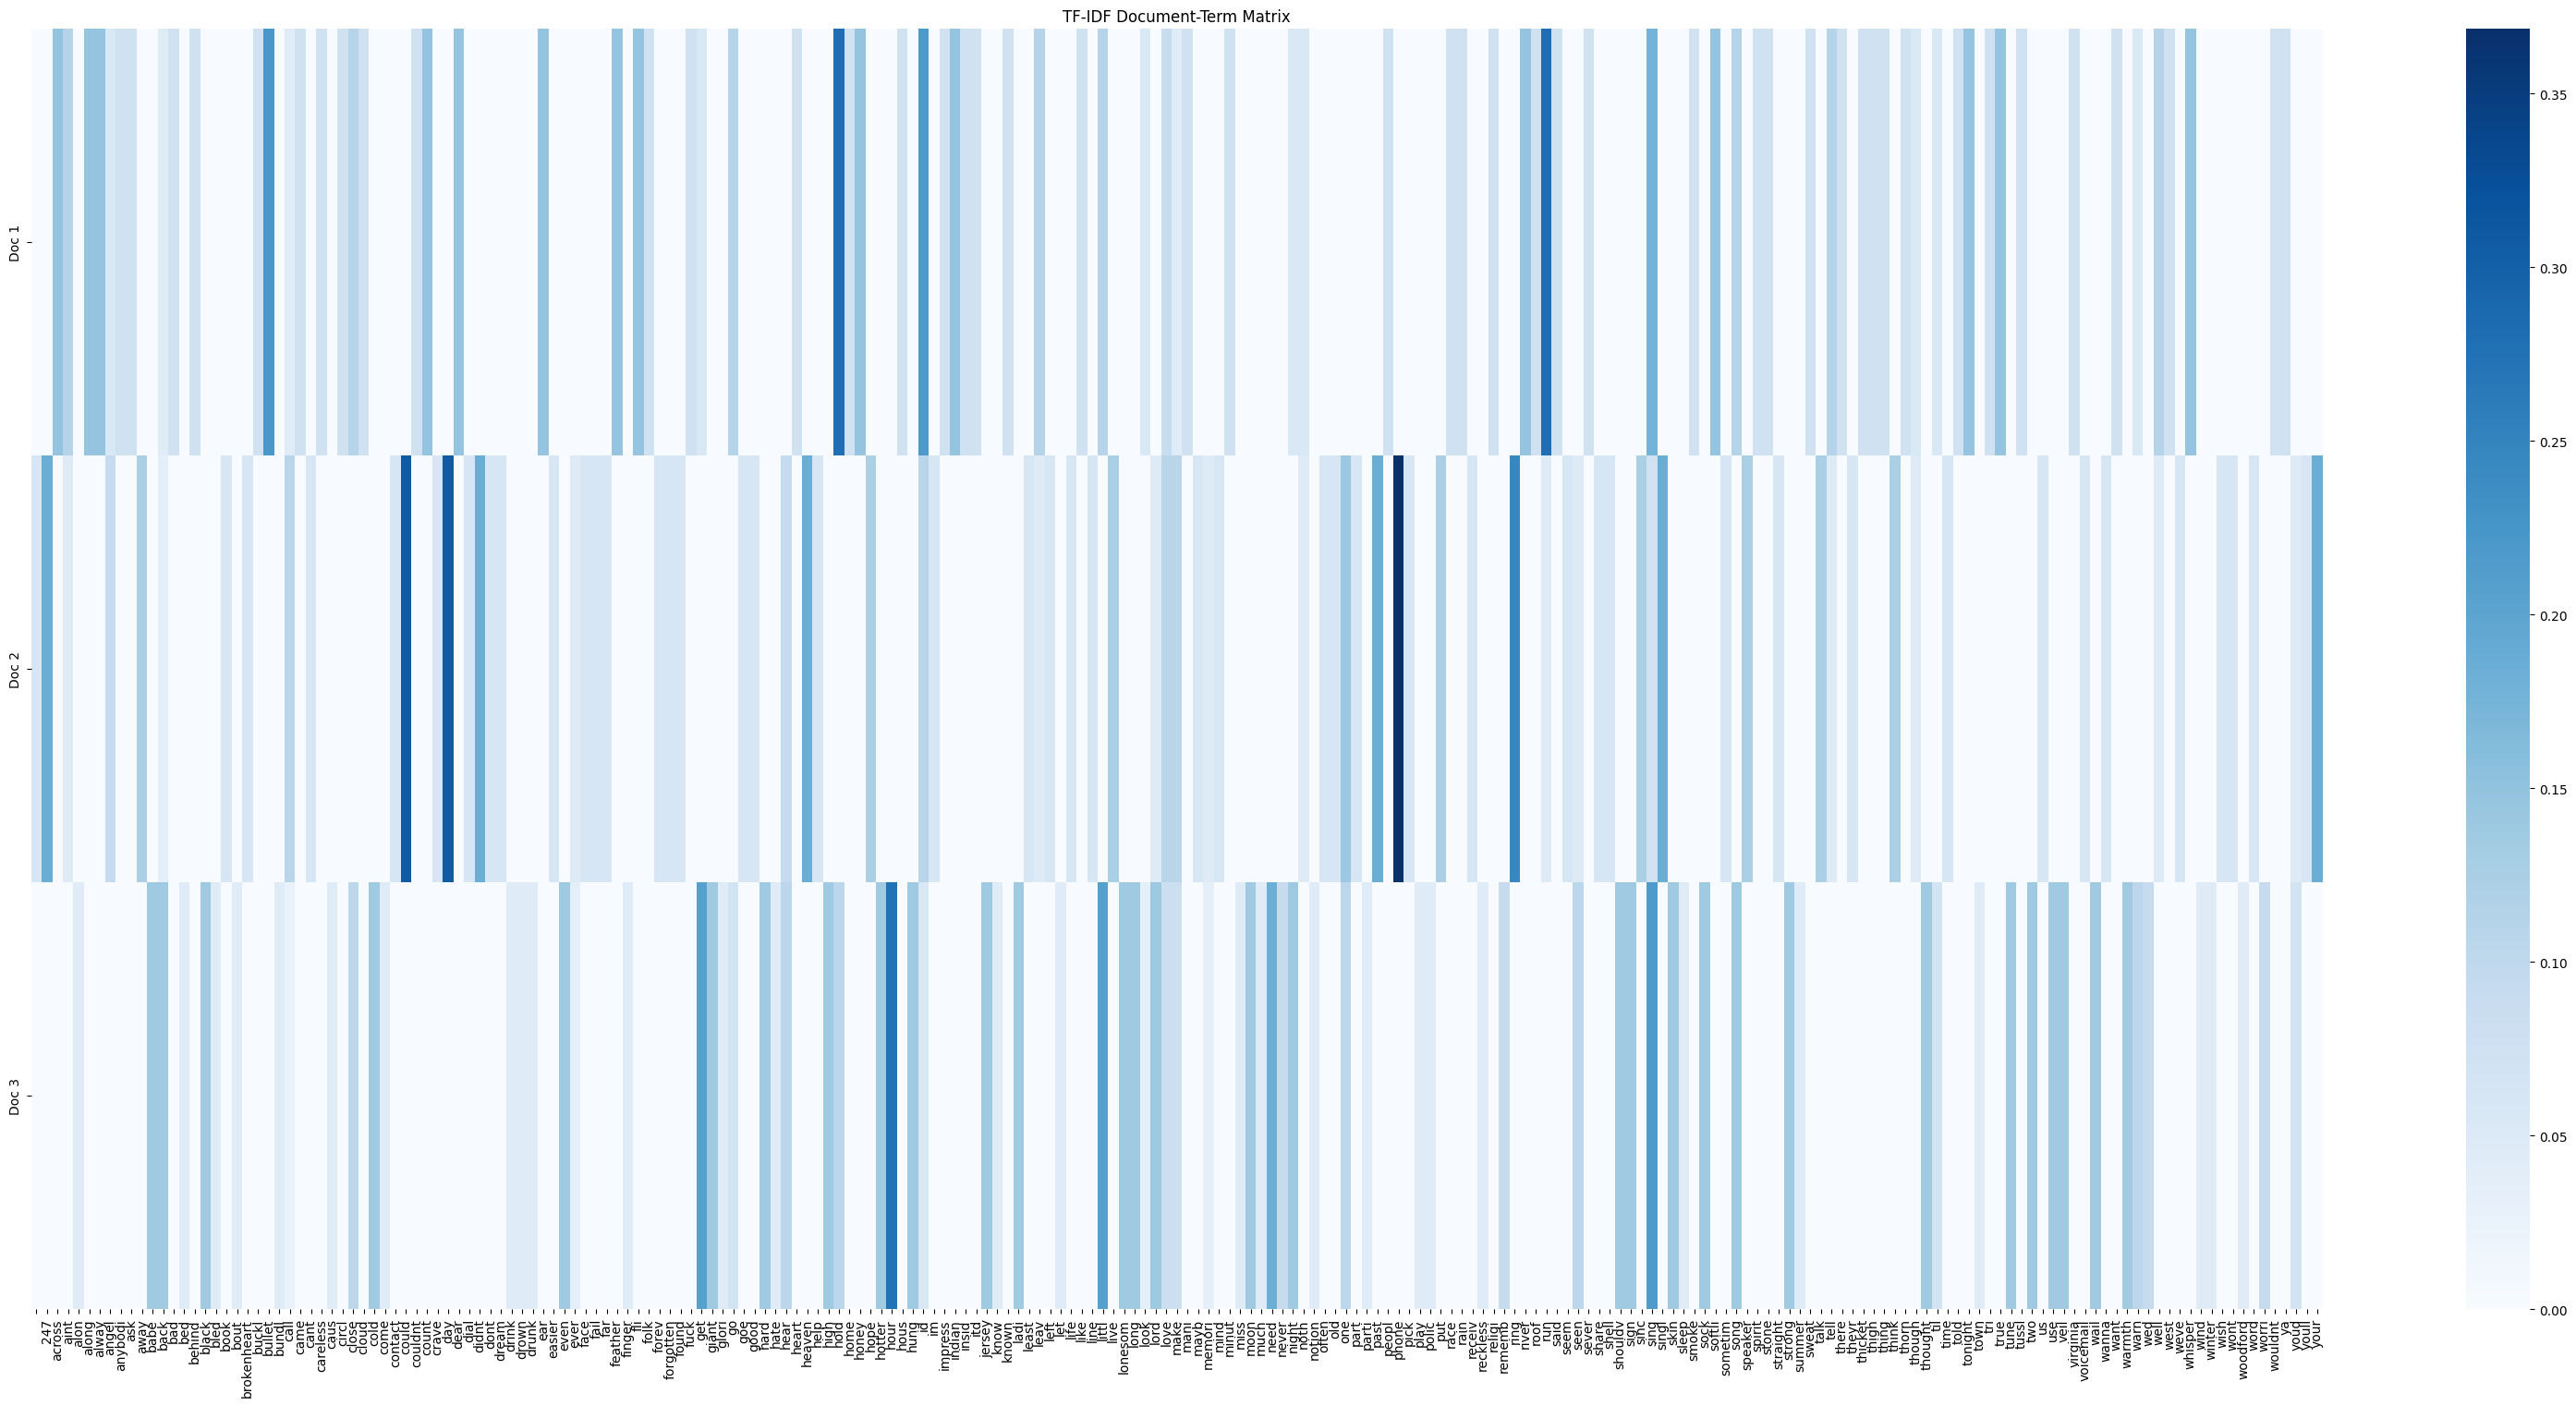

In [32]:
# visualize tfidf matrix with words along axes
terms_tfidf = tfidf_vect.get_feature_names_out()
fig = plt.figure(figsize=(40,18))
sns.heatmap(X1_tfidf.todense(),cmap='Blues' ,xticklabels=terms_tfidf, yticklabels=[f'Doc {i+1}' for i in range(X1_tfidf.shape[0])])
plt.title('TF-IDF Document-Term Matrix')
plt.show()

#### Cosine Similarity with TF-IDF between Document 1 and Document 2

In [33]:
cosine_sim_tfidf_one_two = cosine_similarity(X1_tfidf[0], X1_tfidf[1])
print(f"Cosine similarity between Doc1 and Do2 using TF-IDF: {cosine_sim_tfidf_one_two[0][0]}")
print(f"In radians: {np.arccos(cosine_sim_tfidf_one_two[0][0])}")
print(f"In degrees: {np.rad2deg(np.arccos(cosine_sim_tfidf_one_two[0][0]))}")

Cosine similarity between Doc1 and Do2 using TF-IDF: 0.10143973850874774
In radians: 1.469181808250896
In degrees: 84.17791695017493


#### Cosine Similarity with TF-IDF between Document 1 and Document 3

In [34]:
cosine_sim_tfidf_one_three = cosine_similarity(X1_tfidf[0], X1_tfidf[2])
print(f"Cosine similarity between Doc1 and Do2 using TF-IDF: {cosine_sim_tfidf_one_three[0][0]}")
print(f"In radians: {np.arccos(cosine_sim_tfidf_one_three[0][0])}")
print(f"In degrees: {np.rad2deg(np.arccos(cosine_sim_tfidf_one_three[0][0]))}")


Cosine similarity between Doc1 and Do2 using TF-IDF: 0.18603990736084247
In radians: 1.3836661858590356
In degrees: 79.27823270468689


#### Cosine Similarity with TF-IDF between Document 2 and Document 3

In [35]:
cosine_sim_two_three = cosine_similarity(X1_tfidf[1], X1_tfidf[2])
print(f"Cosine similarity between Doc2 and Do3 using TF-IDF: {cosine_sim_two_three[0][0]}")
print(f"In radians: {np.arccos(cosine_sim_two_three[0][0])}")
print(f"In degrees: {np.rad2deg(np.arccos(cosine_sim_two_three[0][0]))}")

Cosine similarity between Doc2 and Do3 using TF-IDF: 0.08925005458525953
In radians: 1.481427357504309
In degrees: 84.87953524021508


In [36]:
tfidf_matrix = cosine_similarity(X1_tfidf)

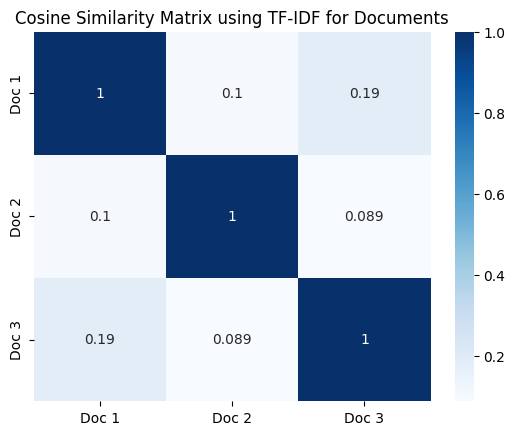

In [37]:
# visualize tfidf_matrix
sns.heatmap(tfidf_matrix, annot=True, cmap='Blues', xticklabels=[f'Doc {i+1}' for i in range(X1_tfidf.shape[0])], yticklabels=[f'Doc {i+1}' for i in range(X1_tfidf.shape[0])])
plt.title('Cosine Similarity Matrix using TF-IDF for Documents')
plt.show()